In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOKS_DIR = Path.cwd().resolve()
if NOTEBOOKS_DIR.name != "notebooks":
    if (NOTEBOOKS_DIR / "notebooks").exists():
        NOTEBOOKS_DIR = NOTEBOOKS_DIR / "notebooks"
    elif NOTEBOOKS_DIR.parent.name == "notebooks":
        NOTEBOOKS_DIR = NOTEBOOKS_DIR.parent
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOKS_DIR))

from config import PATHS

In [2]:
with open(PATHS["gene2id_map"], 'rb') as f: 
    gene2id_map = pkl.load(f)
with open(PATHS["cancer_list"]) as f:
    cancer_list = [line.rstrip('\n') for line in f]

In [3]:
id2gene_map = {i:g for g,i in gene2id_map.items()}
id2cancer_map = {i:cancer for i,cancer in enumerate(cancer_list)}
cancer2id_map = {cancer:i for i,cancer in enumerate(cancer_list)}

In [4]:
res_dir = PATHS["all_sl_inference_dir"]

#### Embedding similarity

In [5]:
def get_emb(name):
    with open(os.path.join(res_dir, f"{name}_transformeremb.pkl"), 'rb') as f:  
        emb = pkl.load(f)
    ## (5/fold, 2genes/pair, 11727pairs)
    ## emb: (20, 512)
    
    if emb[0][0].ndim == 2:
        emb_gene1 = [emb[i][0] for i in range(5)]
        emb_gene2 = [emb[i][1] for i in range(5)]
    else:
        emb_gene1 = [emb[i][0][:,0,:] for i in range(5)]
        emb_gene2 = [emb[i][1][:,0,:] for i in range(5)]
    emb1_cat = np.concatenate(emb_gene1, axis=0)
    emb2_cat = np.concatenate(emb_gene2, axis=0)
    emb_total = np.concatenate([emb1_cat, emb2_cat], axis=0)

    df_all = [pd.read_csv(os.path.join(res_dir, f"pred_{name}_cv{cv}.csv")) for cv in range(1,6)]
    context_cat = pd.concat([df['cancer'] for df in df_all]).tolist()*2
    gene1_cat = pd.concat([df['primary_gene'] for df in df_all]).tolist()
    gene2_cat = pd.concat([df['partner_gene'] for df in df_all]).tolist()
    gene_total = gene1_cat+gene2_cat
    gene_total_df = pd.DataFrame({'gene':gene_total,'context':context_cat})
    gene_total_df = gene_total_df.drop_duplicates(keep='first')
    unique_idx = gene_total_df.index

    gene_unique = [gene_total[i] for i in unique_idx]
    emb_unique = emb_total[unique_idx, :]
    context_unique = [context_cat[i] for i in unique_idx]

    return gene_unique, emb_unique, context_unique
    

In [6]:
def cos_sim(A,B):
    dot_product = np.dot(A, B)

    norm_A = np.linalg.norm(A)
    norm_B = np.linalg.norm(B)
    cosine_similarity = dot_product / (norm_A * norm_B)

    return cosine_similarity


def calc_sim(gene, emb, context, n_sample=50):
    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    gene_selected = gene_context_df['gene'].value_counts().index[:n_sample]
    np.random.seed(1)
    cos_sim_all = []
    
    for g in gene_selected:
        gene_df = gene_context_df[gene_context_df['gene']==g]
        idx = gene_df.index
        for i in range(len(gene_df)):
            for j in range(i+1, len(gene_df)):
                cos_sim_all.append({
                    'gene': g,
                    'cancer1': gene_df['context'][idx[i]],
                    'cancer2': gene_df['context'][idx[j]],
                    'cos_sim': cos_sim(emb[idx[i]], emb[idx[j]])
                })

    return gene_selected, pd.DataFrame(cos_sim_all)

def calc_sim_geneformer(gene_selected):
    with open(PATHS["geneformer_emb_map"], 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    try:
        for g in gene_selected:
            g_idx = gene2id_map[g]
            for i in range(8):
                for j in range(i+1,8):
                    cos_sim_all.append({
                        'gene': g,
                        'cancer1': id2cancer_map[i],
                        'cancer2': id2cancer_map[j],
                        'cos_sim': cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx])
                    })
    except:
        print(f"not found {g_idx}")

    return pd.DataFrame(cos_sim_all)


In [7]:
gene, emb, context = get_emb("mix_slformer_kg")
gene_selected, cos_sim_all_kg = calc_sim(gene, emb, context)

In [8]:
cos_sim_geneformer = calc_sim_geneformer(gene_selected)

not found 6623


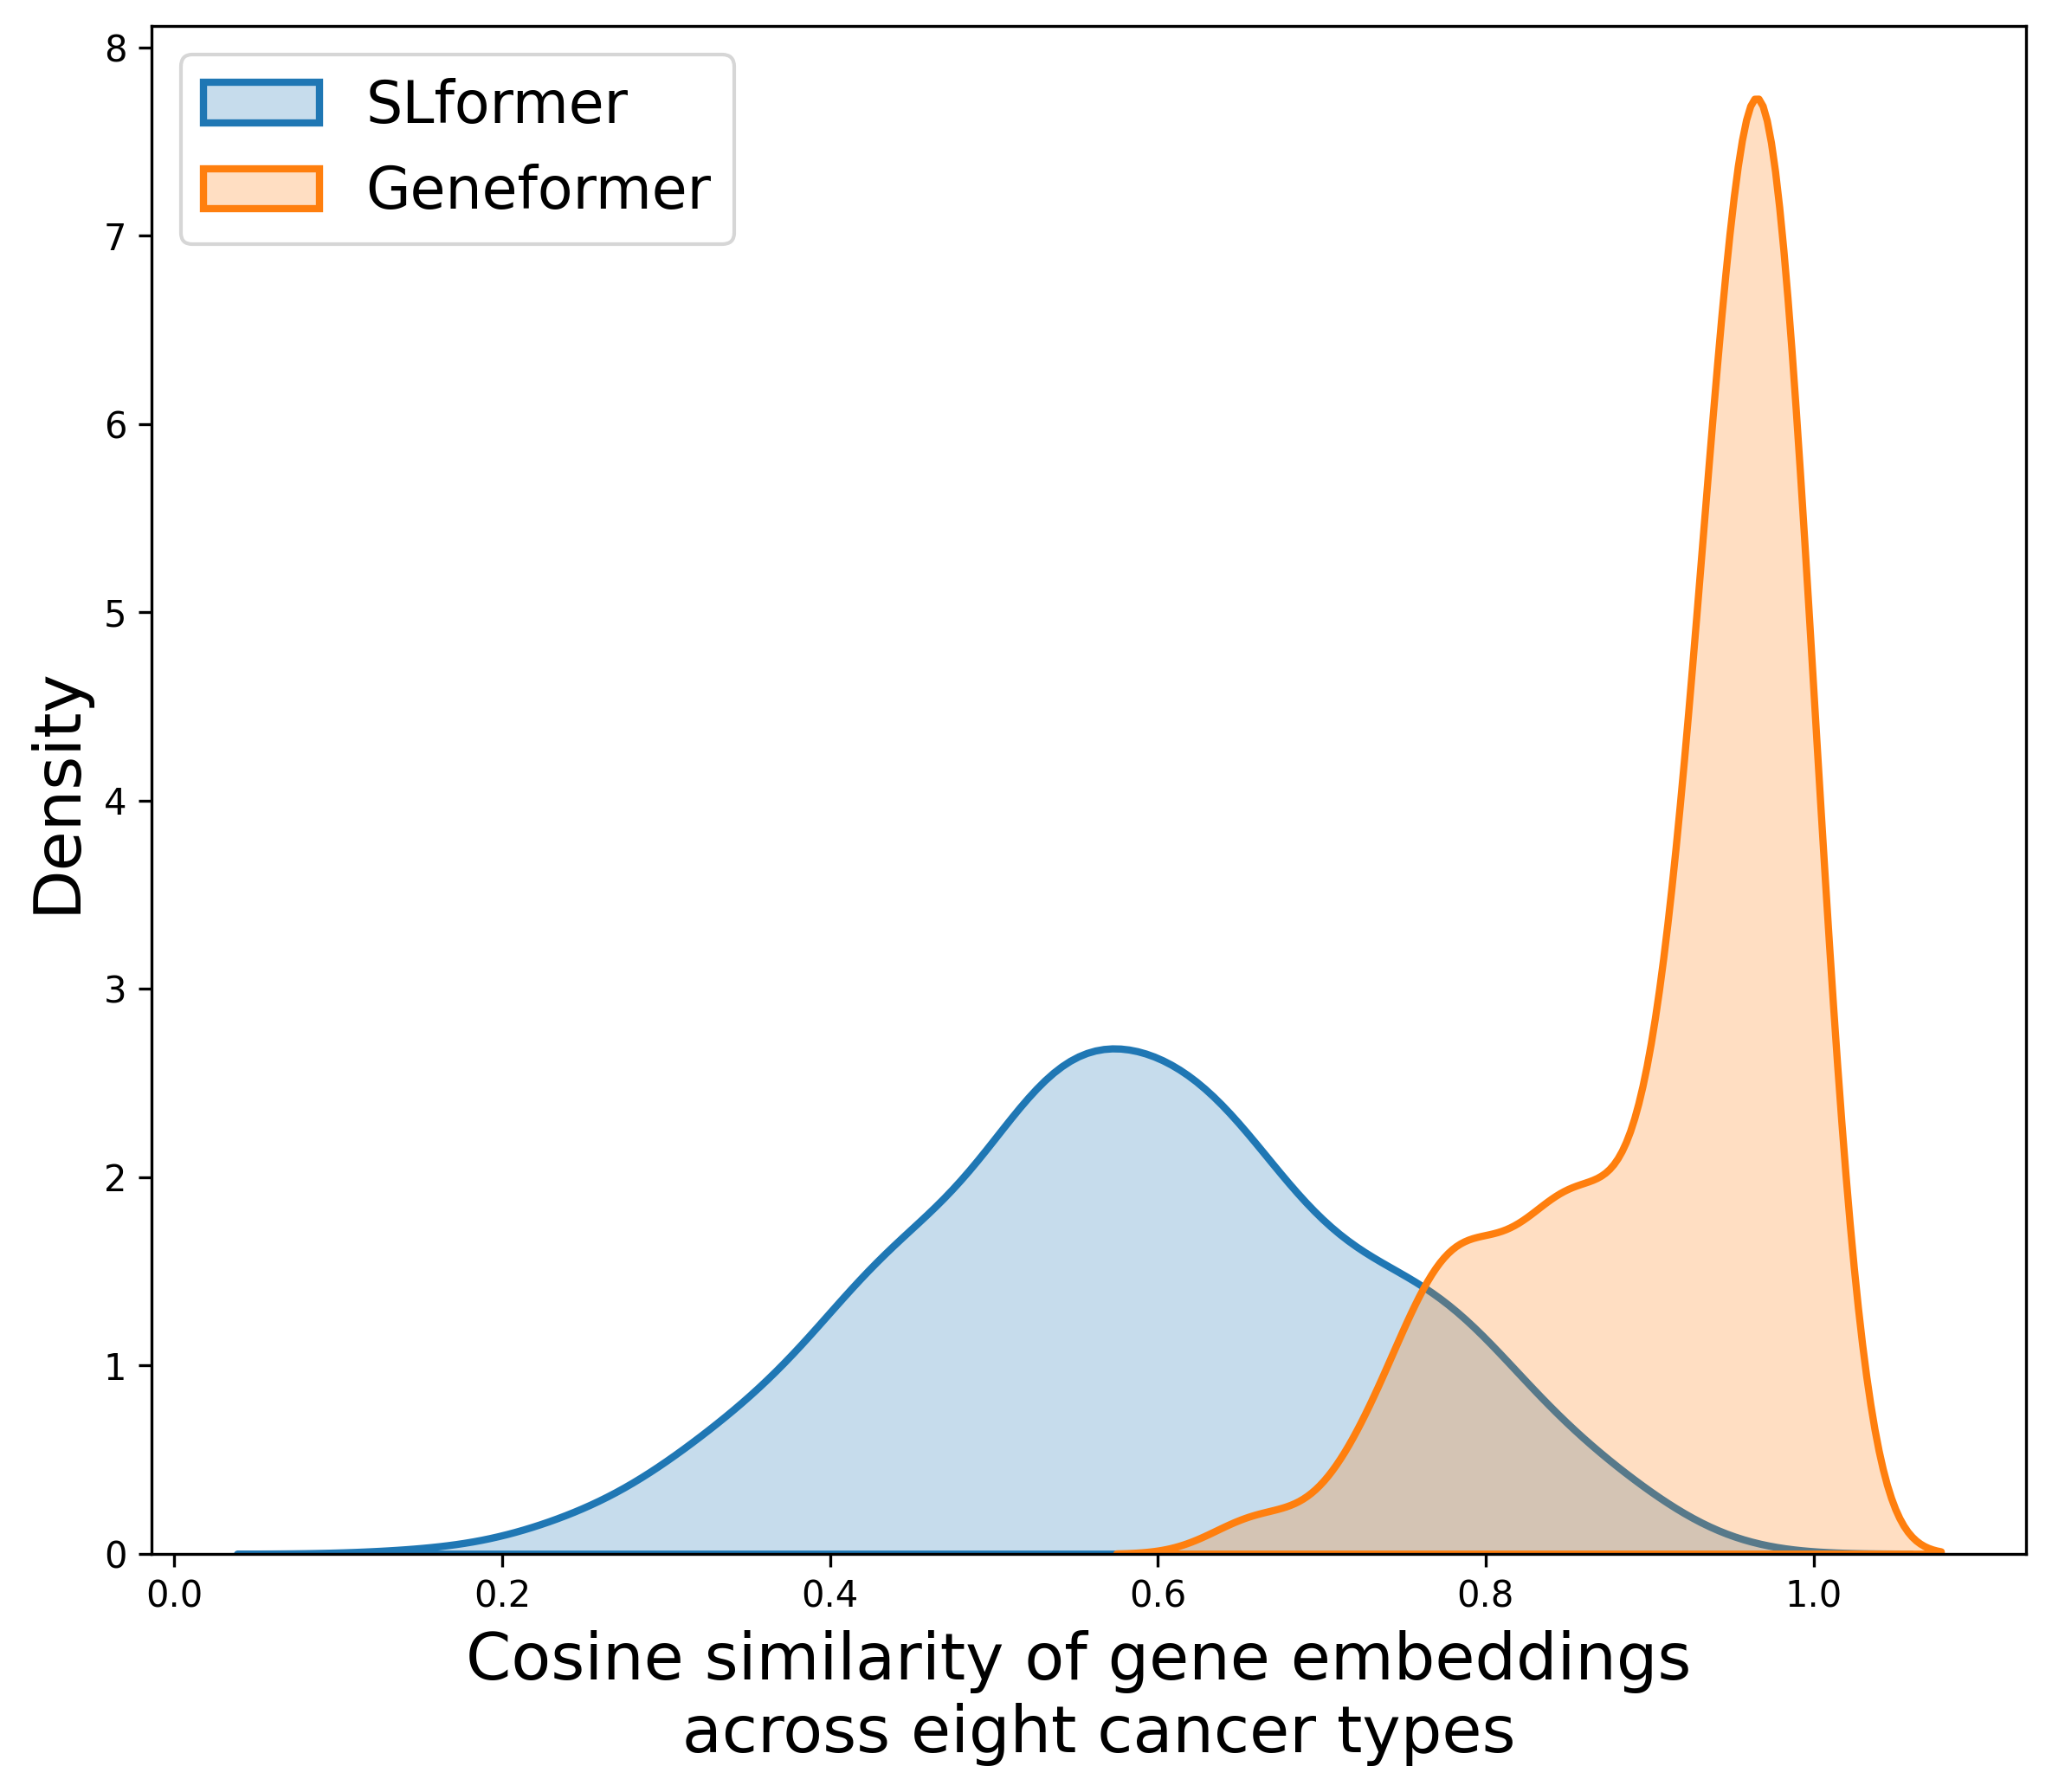

In [9]:
bins = 30
plt.figure(figsize=(8, 7), dpi=300)

sns.kdeplot(cos_sim_all_kg['cos_sim'], fill=True, linewidth=2, label='SLformer') ## color=''
sns.kdeplot(cos_sim_geneformer['cos_sim'], fill=True, linewidth=2, label='Geneformer')

plt.legend(loc='upper left', fontsize=16)
plt.xlabel('Cosine similarity of gene embeddings \n across eight cancer types', 
           fontsize=18)
plt.ylabel('Density', fontsize=18)
plt.tight_layout()
plt.savefig("./emb_diff_context.pdf", dpi=300, bbox_inches='tight')
plt.show()

#### Functional similarity

In [10]:
from goatools.obo_parser import GODag
from goatools.associations import read_gaf

go_dag = GODag(PATHS["go_basic_obo"])
annotations = read_gaf(PATHS["goa_human_gaf"], go_dag=go_dag)

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/goatools/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/home/jienihu/sc/SLformer/data/GO/go-basic.obo: fmt(1.2) rel(2024-06-17) 45,494 Terms
HMS:0:00:14.648921 707,170 annotations READ: /home/jienihu/sc/SLformer/data/GO/goa_human.gaf 
36129 IDs in loaded association branch, BP


In [11]:
id_mapping = pd.read_csv(PATHS["idmapping_tsv"], sep='\t')
id_mapping = dict(zip(id_mapping['From'], id_mapping['To']))

In [12]:
anno_mapped = {}
for k, v in annotations.items():
    if k in id_mapping:
        anno_mapped[id_mapping[k]] = v

In [13]:
len(anno_mapped.keys())

17575

In [14]:
def find_shared_goterms(gene1, gene2):

    go_terms_gene1 = {go_id for go_id in anno_mapped.get(gene1, [])}
    go_terms_gene2 = {go_id for go_id in anno_mapped.get(gene2, [])}

    shared_go_terms = go_terms_gene1.intersection(go_terms_gene2)

    return len(shared_go_terms)


def pairs_shared_goterms(df):

    ngoterm_all = []

    for i in range(len(df)):
        gene1 = df['gene1'][i]
        gene2 = df['gene2'][i]
        nshared_go_terms = find_shared_goterms(gene1, gene2)
        ngoterm_all.append(nshared_go_terms)

    return ngoterm_all


In [15]:
def calc_sim_genes(gene, emb, context, n_sample=50):

    gene_context_df = pd.DataFrame({"gene": gene, "context": context})
    context_all = list(set(gene_context_df['context']))
    context_all.sort()
    np.random.seed(1)
    cos_sim_all = []

    for cancer in context_all:
        df_cancer = gene_context_df[gene_context_df['context']==cancer]
        df_pairs = [df_cancer.sample(2, random_state=i, replace=False) for i in range(n_sample)]

        for pairs in df_pairs:
            idx = pairs.index
            cos_sim_all.append({
                'gene1': pairs['gene'].iloc[0],
                'gene2': pairs['gene'].iloc[1],
                'context': cancer,
                'cos_sim': cos_sim(emb[idx[0]], emb[idx[1]])
            })
        
    return pd.DataFrame(cos_sim_all)


def calc_sim_genes_geneformer(df):
    with open(PATHS["geneformer_emb_map"], 'rb') as f: 
        geneformer_emb = pkl.load(f)
    cos_sim_all = []

    for i, row in df.iterrows():
        try:
            cancer_idx = cancer2id_map[row['context']]
            g1_idx = gene2id_map[row['gene1']]
            g2_idx = gene2id_map[row['gene2']]
            cos_sim_all.append({
                'gene1': row['gene1'],
                'gene2': row['gene2'],
                'context': row['context'],
                'cos_sim': cos_sim(geneformer_emb[cancer_idx][g1_idx], geneformer_emb[cancer_idx][g2_idx])
            })
            # cos_sim_all.append(cos_sim(geneformer_emb[i][g_idx], geneformer_emb[j][g_idx]))
        except:
            print(f"not found genes")

    return pd.DataFrame(cos_sim_all)

In [16]:
gene, emb, context = get_emb("mix_slformer_kg")
cos_sim_all_kg = calc_sim_genes(gene, emb, context, n_sample=5000)

In [17]:
cos_sim_all_geneformer = calc_sim_genes_geneformer(cos_sim_all_kg)

In [18]:
nshared_go_terms = pairs_shared_goterms(cos_sim_all_kg)

In [19]:
cos_sim_all_kg['nshared_go_terms'] = nshared_go_terms
cos_sim_all_geneformer['nshared_go_terms'] = nshared_go_terms

cos_sim_all_kg = cos_sim_all_kg.sort_values(by='nshared_go_terms', ascending=False)
cos_sim_all_geneformer = cos_sim_all_geneformer.sort_values(by='nshared_go_terms', ascending=False)

In [20]:
cos_sim_all_kg = cos_sim_all_kg.drop_duplicates(keep='first')
cos_sim_all_geneformer = cos_sim_all_geneformer.drop_duplicates(keep='first')

In [21]:
def plot_func_sim_allcancer(df, savename, go_thr=3):

    plt.figure(figsize=(8, 3.5), dpi=300)
    
    df_high = df[df['nshared_go_terms']>=go_thr]
    df_low = df[df['nshared_go_terms']==0]
    df_low = df_low.iloc[-len(df_high):,:]  ## gene pairs with the least number of shared GO terms

    sns.kdeplot(df_high['cos_sim'], fill=True, linewidth=2, label='gene pairs with similar functions', color='#1CE17F')
    sns.kdeplot(df_low['cos_sim'], fill=True, linewidth=2, label='gene pairs with dissimilar functions', color='#FA512F')

    # plt.title(title, fontsize=15)
    plt.xlabel('Cosine Similarity of pairs of gene embeddings \n in the same cancer', 
               fontsize=16)
    plt.ylabel('Density', fontsize=16)
    plt.legend(fontsize=12)
    plt.savefig(f"./{savename}.pdf", dpi=300, bbox_inches='tight')
    plt.show()



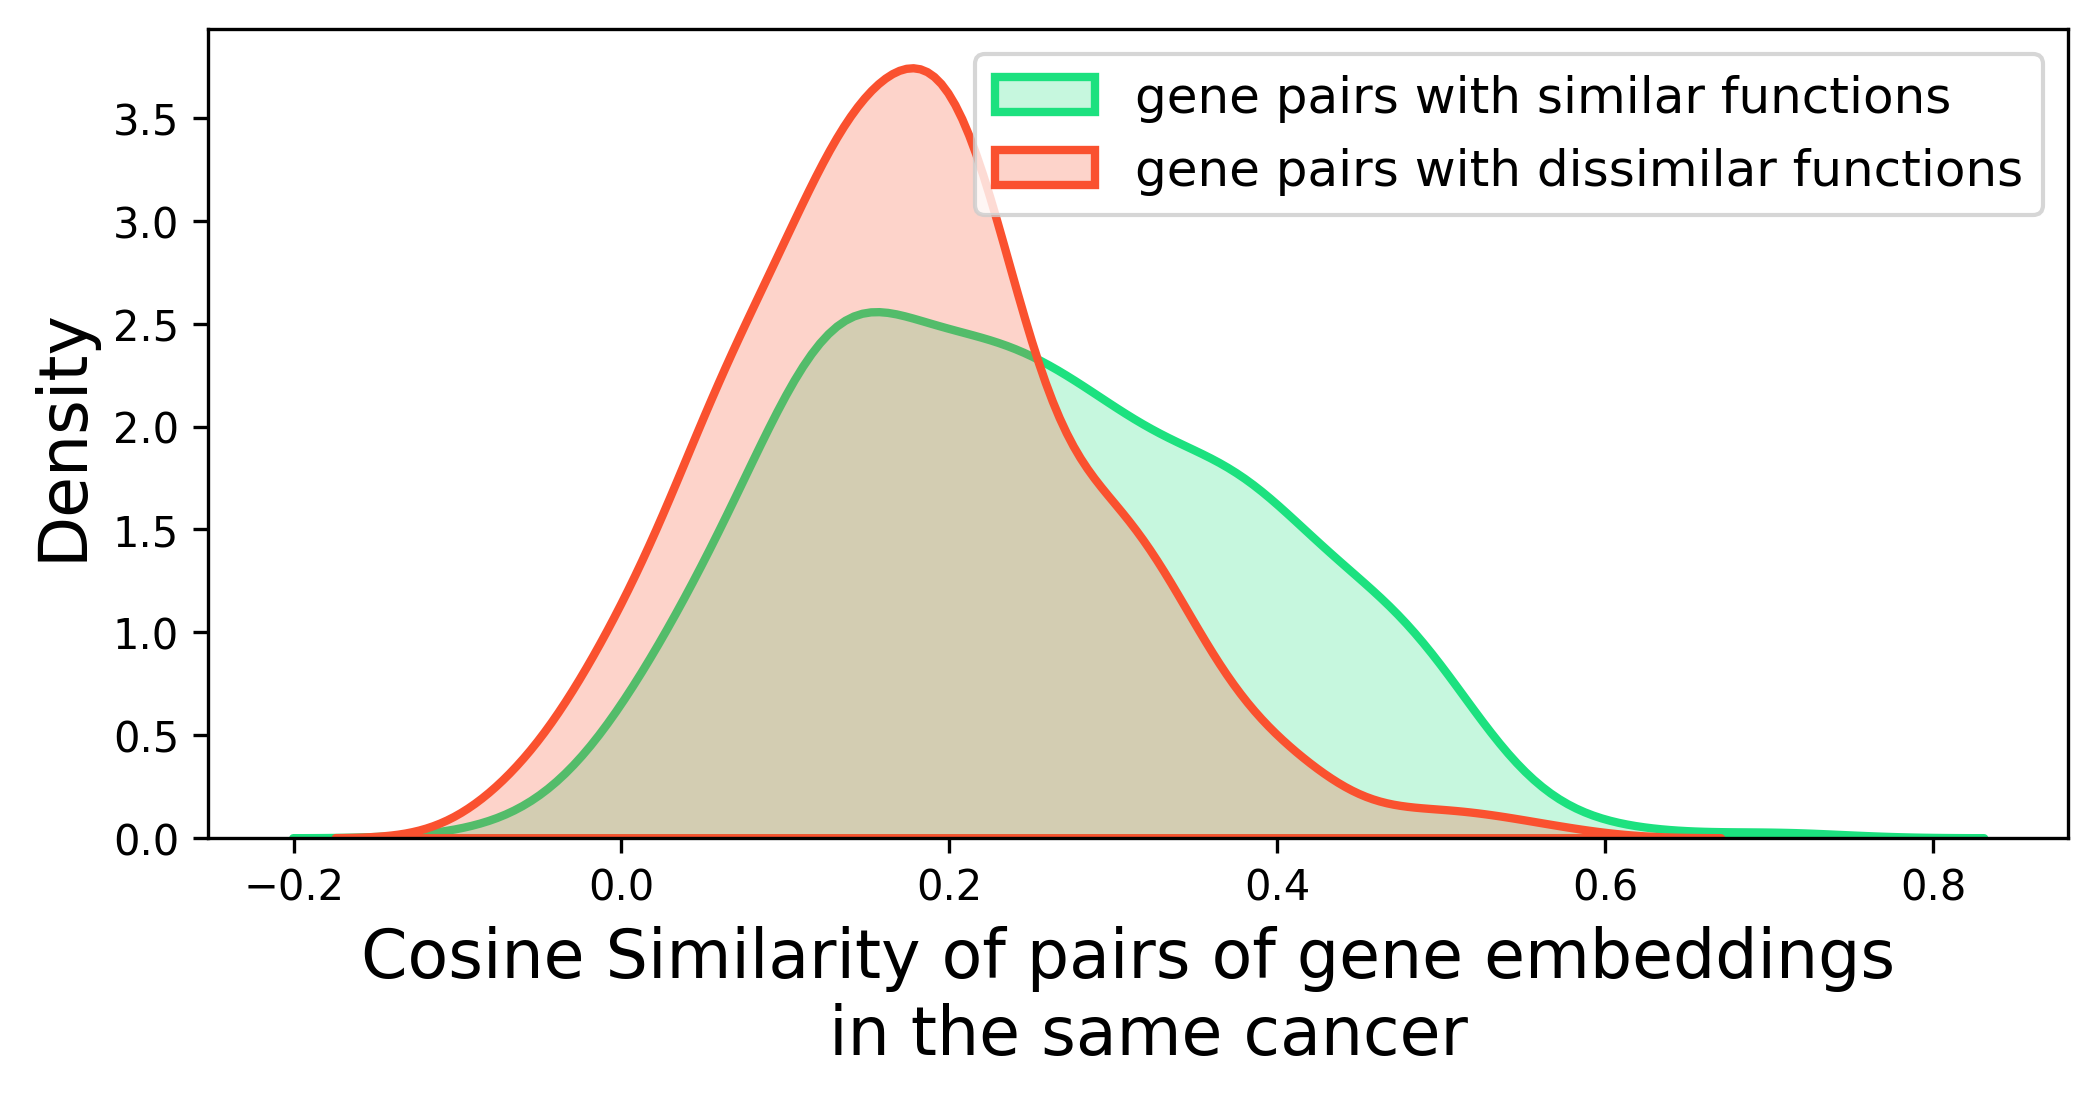

In [22]:
plot_func_sim_allcancer(cos_sim_all_kg, savename="emb_diff_func_trained_slformer", go_thr=5)

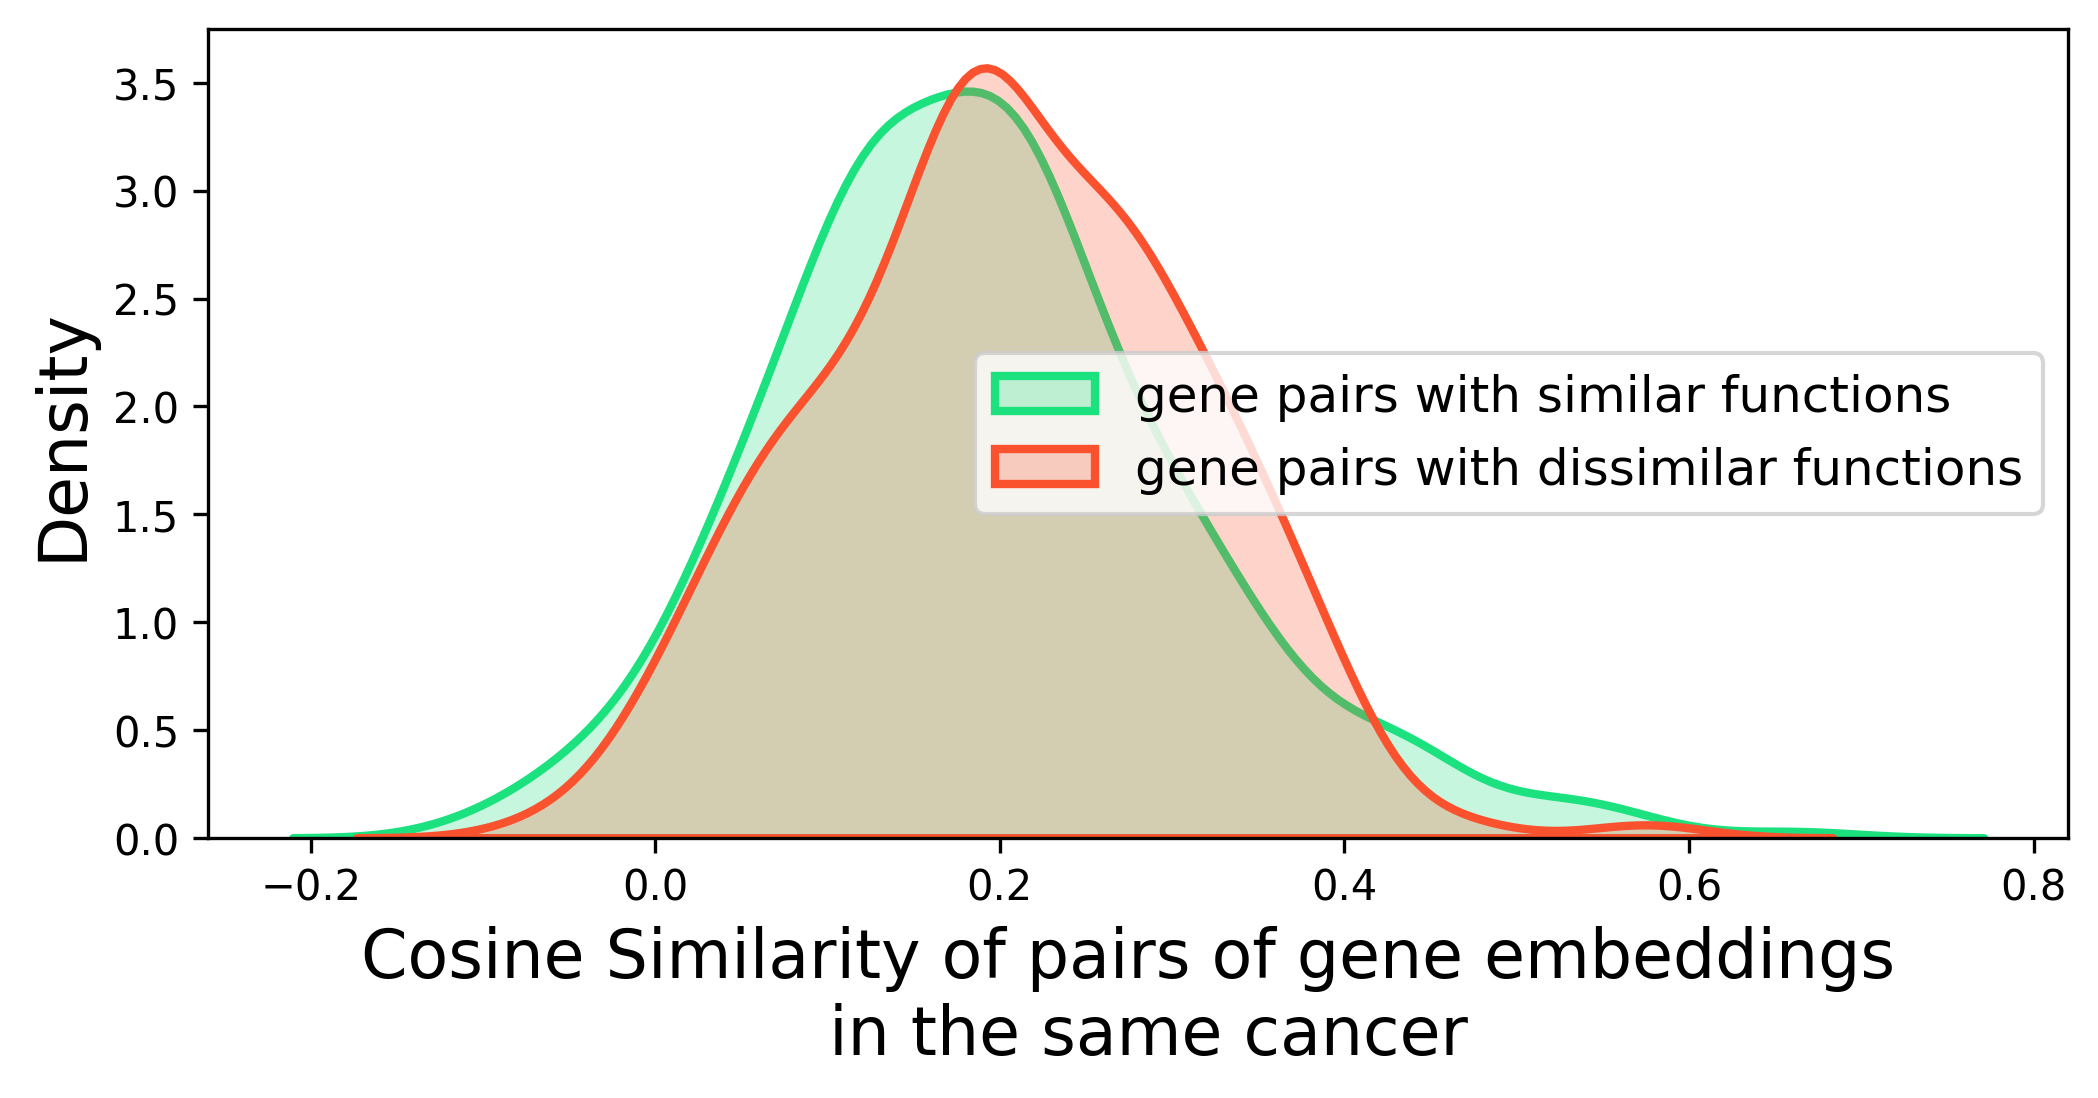

In [23]:
plot_func_sim_allcancer(cos_sim_all_geneformer, savename="emb_diff_func_pretrained_geneformer", go_thr=5)